In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
import scienceplots
plt.style.use(['science', 'no-latex'])

# Allow more columns to be displayed
pd.set_option("display.max_columns", None)

import logging
logging.basicConfig(level=logging.WARNING)


IMAGES_PATH = "/Users/klemenkubelj/Documents/school/graduate/masters/code/cvar-masters-thesis-2025/figures"

In [3]:
from utils.flood_request_utils import (
    residential_damage_fractions,
    commercial_damage_function,
    industrial_damage_function,
    agriculture_damage_function,

    get_damage_fraction,
)

In [4]:
plt.rcParams.update({
    'font.size': 14,          # General font size
    'axes.titlesize': 16,     # Title font size
    'axes.labelsize': 14,     # X and Y label font size
    'xtick.labelsize': 14,    # X-axis tick label size
    'ytick.labelsize': 14,    # Y-axis tick label size
    'legend.fontsize': 12,    # Legend font size
    'figure.titlesize': 18,    # Figure title (suptitle) font size

    "axes.axisbelow": True
})

In [5]:
!which python

/Users/klemenkubelj/miniconda3/envs/cvar-masters/bin/python


In [6]:
df = pd.read_csv(os.path.join("../data/vloge_processed_2025-05-10.csv"))
print("Original shape:", df.shape)

# Show number of samples, split by event
event_sample_counts = df["DogodekId"].value_counts()
print("Number of samples split by event:")
print(event_sample_counts)
print("Before filtering:", df.shape)

# df["relative_damage"] = df["SkupnaSkoda"] / df["Vrednost"]
df["relative_damage"] = df["OdstPoskodovanostiObjekta"] / 100
df["Objekt_VisinaVodeM"] = df["Objekt_VisinaVodeCm"] / 100
df = df[
    (df["relative_damage"].notna())
    & (df["relative_damage"]<=1)
    & (df["Objekt_VisinaVodeM"].notna())
    # & (df["Objekt_VisinaVodeM"]<=2.5)
    & (df["Objekt_VisinaVodeM"]>=0)
]
# Cap relative damage at 1
df["relative_damage"] = df["relative_damage"].clip(upper=1)
print("--------------------------------")
# Create water height buckets (every 50cm up to 200cm)
# bucket_edges = np.arange(0, 2.01, 0.5)
min_depth = 0
max_depth = 2
bucket_width = 0.5
bucket_edges = np.arange(min_depth, max_depth + 0.1, bucket_width)
print("Bucket edges:")
print(bucket_edges)
df["water_height_bucket"] = pd.cut(
    df["Objekt_VisinaVodeM"], 
    bins=bucket_edges,
    labels=[f"{i}-{i+0.5}m" for i in np.arange(min_depth, max_depth, bucket_width)]
)
print("Number of samples split by water height bucket:")
water_height_sample_counts = df["water_height_bucket"].value_counts()
print(water_height_sample_counts)

print("--------------------------------")
# Set property_type based on "Objekt_VrstaObjektaId"
df["property_type"] = df["Objekt_VrstaObjektaId"].map({
    1: "industrial",
    2: "residential",
    4: "commercial",
    5: "agriculture",
})
# Remove nana values
df = df[df["property_type"].notna()]
print("Number of samples split by property_type:")
property_type_sample_counts = df["property_type"].value_counts()
print(property_type_sample_counts)

print("--------------------------------")
print("After filtering:", df.shape)

Original shape: (20040, 18)
Number of samples split by event:
DogodekId
68    12389
14     3086
18     2415
24     2150
Name: count, dtype: int64
Before filtering: (20040, 18)
--------------------------------
Bucket edges:
[0.  0.5 1.  1.5 2. ]
Number of samples split by water height bucket:
water_height_bucket
0.0-0.5m    1856
0.5-1.0m    1473
1.0-1.5m     827
1.5-2.0m     597
Name: count, dtype: int64
--------------------------------
Number of samples split by property_type:
property_type
residential    3249
agriculture     586
commercial      218
industrial      147
Name: count, dtype: int64
--------------------------------
After filtering: (4200, 22)


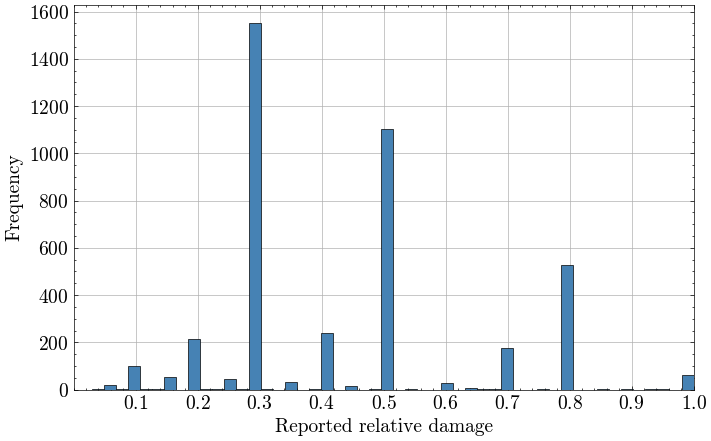

In [7]:
plt.figure(figsize=(8, 5))
# sns.histplot(df["relative_damage"], bins=50)
# plt.title("Histogram of Relative Damage")
plt.hist(df["relative_damage"], edgecolor="black", color="steelblue", linewidth=0.5, bins=50)
plt.xlabel("Reported relative damage")
plt.ylabel("Frequency")
plt.grid(True)
plt.xlim(0,1)

plt.xticks(np.arange(0.1, 1.01, 0.1))

plt.savefig(IMAGES_PATH + "/05/validation_damage_histogram.pdf", dpi=300, bbox_inches="tight")
plt.show()


# 1. Calculate predicted relative using depth-damage function

In [8]:
# Calculate damage based on property type
df["predicted_relative_damage"] = df.apply(lambda row: get_damage_fraction(row["Objekt_VisinaVodeM"], row["property_type"]), axis=1)

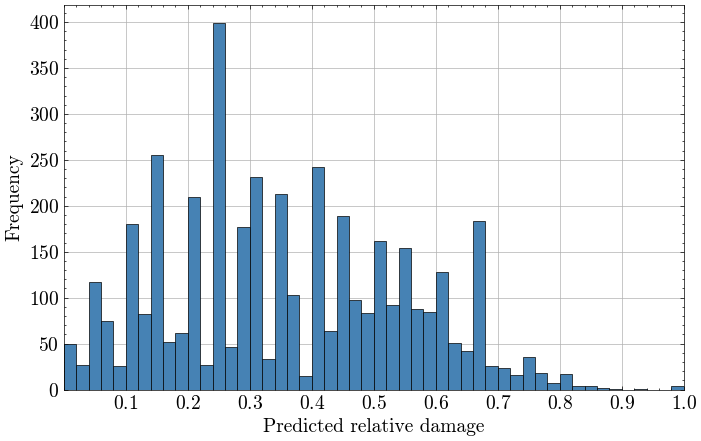

In [9]:
plt.figure(figsize=(8, 5))
# sns.histplot(df["relative_damage"], bins=50)
# plt.title("Histogram of Relative Damage")
plt.hist(df["predicted_relative_damage"], edgecolor="black", color="steelblue", linewidth=0.5, bins=50)
plt.xlabel("Predicted relative damage")
plt.ylabel("Frequency")
plt.grid(True)
plt.xlim(0,1)

plt.xticks(np.arange(0.1, 1.01, 0.1))

plt.savefig(IMAGES_PATH + "/05/predicted_damage_histogram.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
df.head()

,VlogaId,Objekt_Naslov,Objekt_Naslov_PostnaStevilka,Objekt_Parcela_Stevilka,Objekt_Parcela_KoId,Objekt_UporabnaPovrsina,Objekt_VisinaVodeCm,Objekt_StopnjaPoskodovanosti,Objekt_CentroidX,Objekt_CentroidY,Skoda_DatumOcene,Objekt_SkodaPovzrocenaVPlazu,Objekt_VrstaObjektaId,DogodekId,Vrednost,OdstPoskodovanostiObjekta,SkupnaSkoda,SkupnaSkodaSource,relative_damage,Objekt_VisinaVodeM,water_height_bucket,property_type,predicted_relative_damage
206,149162,Čužnja vas 12,8231 TREBELNO,2501/3,1449,35.00,0.0,NaN,515501.0,85416.0,10/15/10 00:00:00,NaN,2.0,14,3309.35,100.0,3309.35,Postavka3,1.0,0.0,NaN,residential,0.0
788,155809,Poklek nad Blanco 10,8283 BLANCA,172/0.S,2307,214.54,0.0,NaN,530288.0,97018.0,10/21/10 00:00:00,NaN,2.0,14,72396.27,100.0,72396.27,Postavka3,1.0,0.0,NaN,residential,0.0
1296,152700,Vrh nad Laškim 3,3270 LAŠKO,187/0.S,1705,161.65,40.0,NaN,521876.0,109619.0,09/28/10 00:00:00,NaN,2.0,14,54338.48,100.0,54338.48,Postavka3,1.0,0.4,0.0-0.5m,residential,0.2
1298,157182,Obrežje pri Zidanem Mostu 50,1432 ZIDANI MOST,576/2,1625,196.41,0.0,NaN,513876.0,104422.0,11/04/10 00:00:00,NaN,2.0,14,61876.97,70.0,43313.88,Postavka3,0.7,0.0,NaN,residential,0.0
1299,157304,Obrežje pri Zidanem Mostu 49,1432 ZIDANI MOST,22/8.S,1625,57.75,0.0,NaN,513884.0,104450.0,11/04/10 00:00:00,NaN,2.0,14,14169.51,100.0,14169.51,Postavka3,1.0,0.0,NaN,residential,0.0


In [11]:
# Show number of samples, split by event
event_sample_counts = df["DogodekId"].value_counts()
print("Number of samples split by event:")
print(event_sample_counts)

Number of samples split by event:
DogodekId
68    4171
18      15
14      13
24       1
Name: count, dtype: int64


In [81]:
# Show number of samples, split by property_type
_sample_counts = df["property_type"].value_counts()
print("Number of samples split by property_type:")
print(_sample_counts)

Number of samples split by property_type:
property_type
residential    3249
agriculture     586
commercial      218
industrial      147
Name: count, dtype: int64


In [82]:
# Show number of samples, split by property_type
_sample_counts = df["water_height_bucket"].value_counts()
print("Number of samples split by water_height_bucket:")
print(_sample_counts)

Number of samples split by water_height_bucket:
water_height_bucket
0.0-0.5m    1527
0.5-1.0m    1144
1.0-1.5m     659
1.5-2.0m     497
Name: count, dtype: int64


(0.0, 300.0)

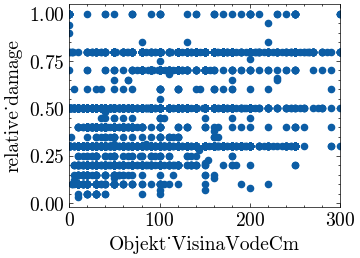

In [83]:

df.plot(x="Objekt_VisinaVodeCm", y="relative_damage", kind="scatter")
plt.xlim(0, 300)

In [131]:
def plot_violin_damage_by_water_height(df, title: str = "", ax=None, fontsize=20):
    _df = df.copy()
    total_samples = len(_df)
    
    # Create the figure and axis
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    else:
        fig = ax.get_figure()

    # Plot violins
    smsplot = sns.violinplot(
        data=_df,
        x="water_height_bucket",
        y="relative_damage",
        cut=0,  # limit the violin plot to actual data range
        ax=ax, # specify the axis to plot on
        color="steelblue",
    )
    smsplot.set_ylabel("Relative damage", fontsize=fontsize)
    smsplot.tick_params(axis="x", labelsize=fontsize)
    smsplot.tick_params(axis="y", labelsize=fontsize)

    # Adjust x-axis to show ticks at the upper bounds of each bucket
    ax.set_xticks(range(len(bucket_edges)-1))
    ax.set_xticklabels([f"{x}m" for x in bucket_edges[1:]])

    # Set y-axis range from 0 to 1
    ax.set_ylim(0, 1)

    # Add count and median annotations for each bucket
    # Calculate and plot median values
    medians = _df.groupby("water_height_bucket", observed=False)["relative_damage"].median()
    for i, median in enumerate(medians):
        # Add horizontal line for median
        ax.hlines(median, i-0.2, i+0.2, colors="black", linestyles="-.", alpha=1)

    # bucket_counts = _df["water_height_bucket"].value_counts().sort_index()
    # for i, (count, median) in enumerate(zip(bucket_counts, medians)):
    #     ax.text(
    #         i,
    #         ax.get_ylim()[0],
    #         f"n={count}\nmed={median:.2f}",
    #         ha="center", va="bottom",
    #         bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    # Customize the plot
    if title != "NO":
        ctitle = f"Distribution of Relative Damage by Water Height (Total Samples: {total_samples})"
        if title:
            ctitle += f" - {title}"
        ax.set_title(ctitle)
    ax.set_xlabel("Water depth [m]")
    ax.set_ylabel("Relative damage")
    ax.tick_params(axis="x", rotation=45)

    # Add grid for better readability
    ax.grid(True, axis="y", linestyle="--", alpha=0.7)
    fig.tight_layout()

    # Hide x 
    
    return fig, ax

def plot_damage_function(damage_function, color="orange", label="NONE", show_title=True, ax=None):
    if ax is None:
        fig = plt.gcf()
        ax = plt.gca()
    else:
        fig = ax.get_figure()

    damage_function = [(h, d) for h, d in damage_function if h <= 2.5]

    flood_depths = [i[0] for i in damage_function]
    damage_fractions = [i[1] for i in damage_function]

    def get_damage_fraction(depth):
        """
        Get damage fraction for a given flood depth using polynomial interpolation.
        For depths outside the range, we clamp the values to [0, 1].
        
        Args:
            depth (float): Flood depth in meters
            
        Returns:
            float: Damage fraction between 0 and 1
        """
        # Create interpolation function
        f = interp1d(flood_depths, damage_fractions, kind="linear", bounds_error=False, fill_value=(0, 1))
        return float(f(depth))

    # Create points for smooth curve visualization
    depths_smooth = np.linspace(0, max(flood_depths), 100)
    damage_smooth = [get_damage_fraction(d) for d in depths_smooth]

    # Plot the data and fitted curve
    ax.plot([(i - 0.5)*2 for i in flood_depths], damage_fractions, "o", color=color)
    # Dont show this in legend
    ax.plot([(i - 0.5)*2 for i in depths_smooth], damage_smooth, "-", label=label, color=color)

    ax.set_xlim(-1, 4)
    
    # Set y-axis range from 0 to 1
    # ax.set_ylim(0, 1)
    
    # Add labels and title
    # ax.set_xlabel("Water Height (m)")
    # ax.set_ylabel("Damage Fraction")
    # ax.set_title("Damage Function")
    # ax.grid(True, linestyle="--", alpha=0.7)
    
    
    # Return the figure and axis for further customization
    return fig, ax


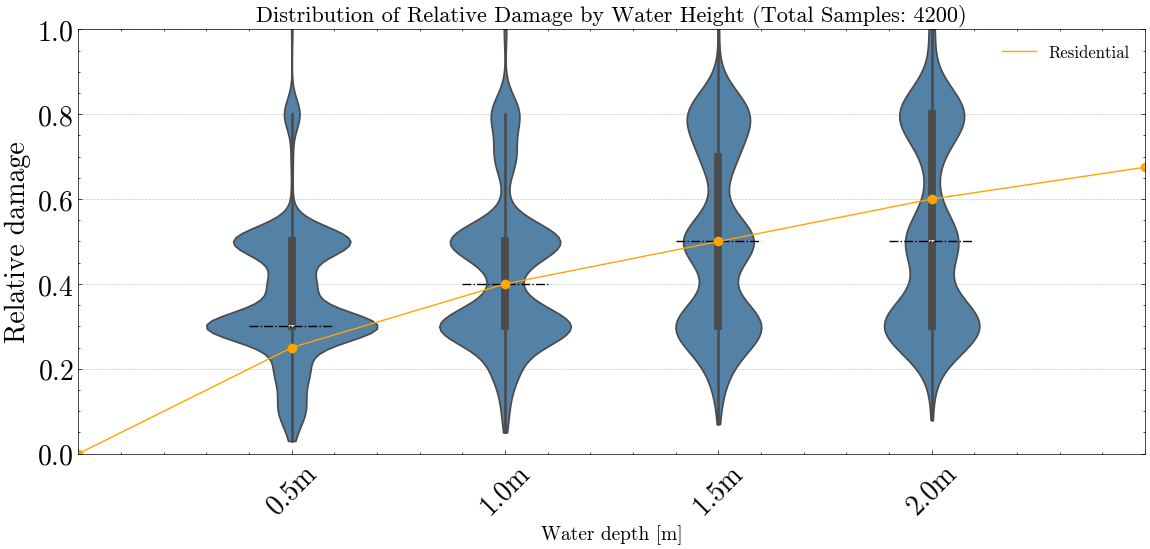

In [132]:
_df = df.copy()
# _df = _df[_df["Objekt_VrstaObjektaId"].isin([1, 2, 4, 5])]
fig, ax = plot_violin_damage_by_water_height(_df)
fig, ax = plot_damage_function(residential_damage_fractions, color="orange", label="Residential")
# fig, ax = plot_damage_function(commercial_damage_function, color="red", label="Commercial")
# fig, ax = plot_damage_function(industrial_damage_function, color="purple", label="Industrial")
# fig, ax = plot_damage_function(agriculture_damage_function, color="green", label="Agriculture")

ax.legend()

Original font size: 20.0


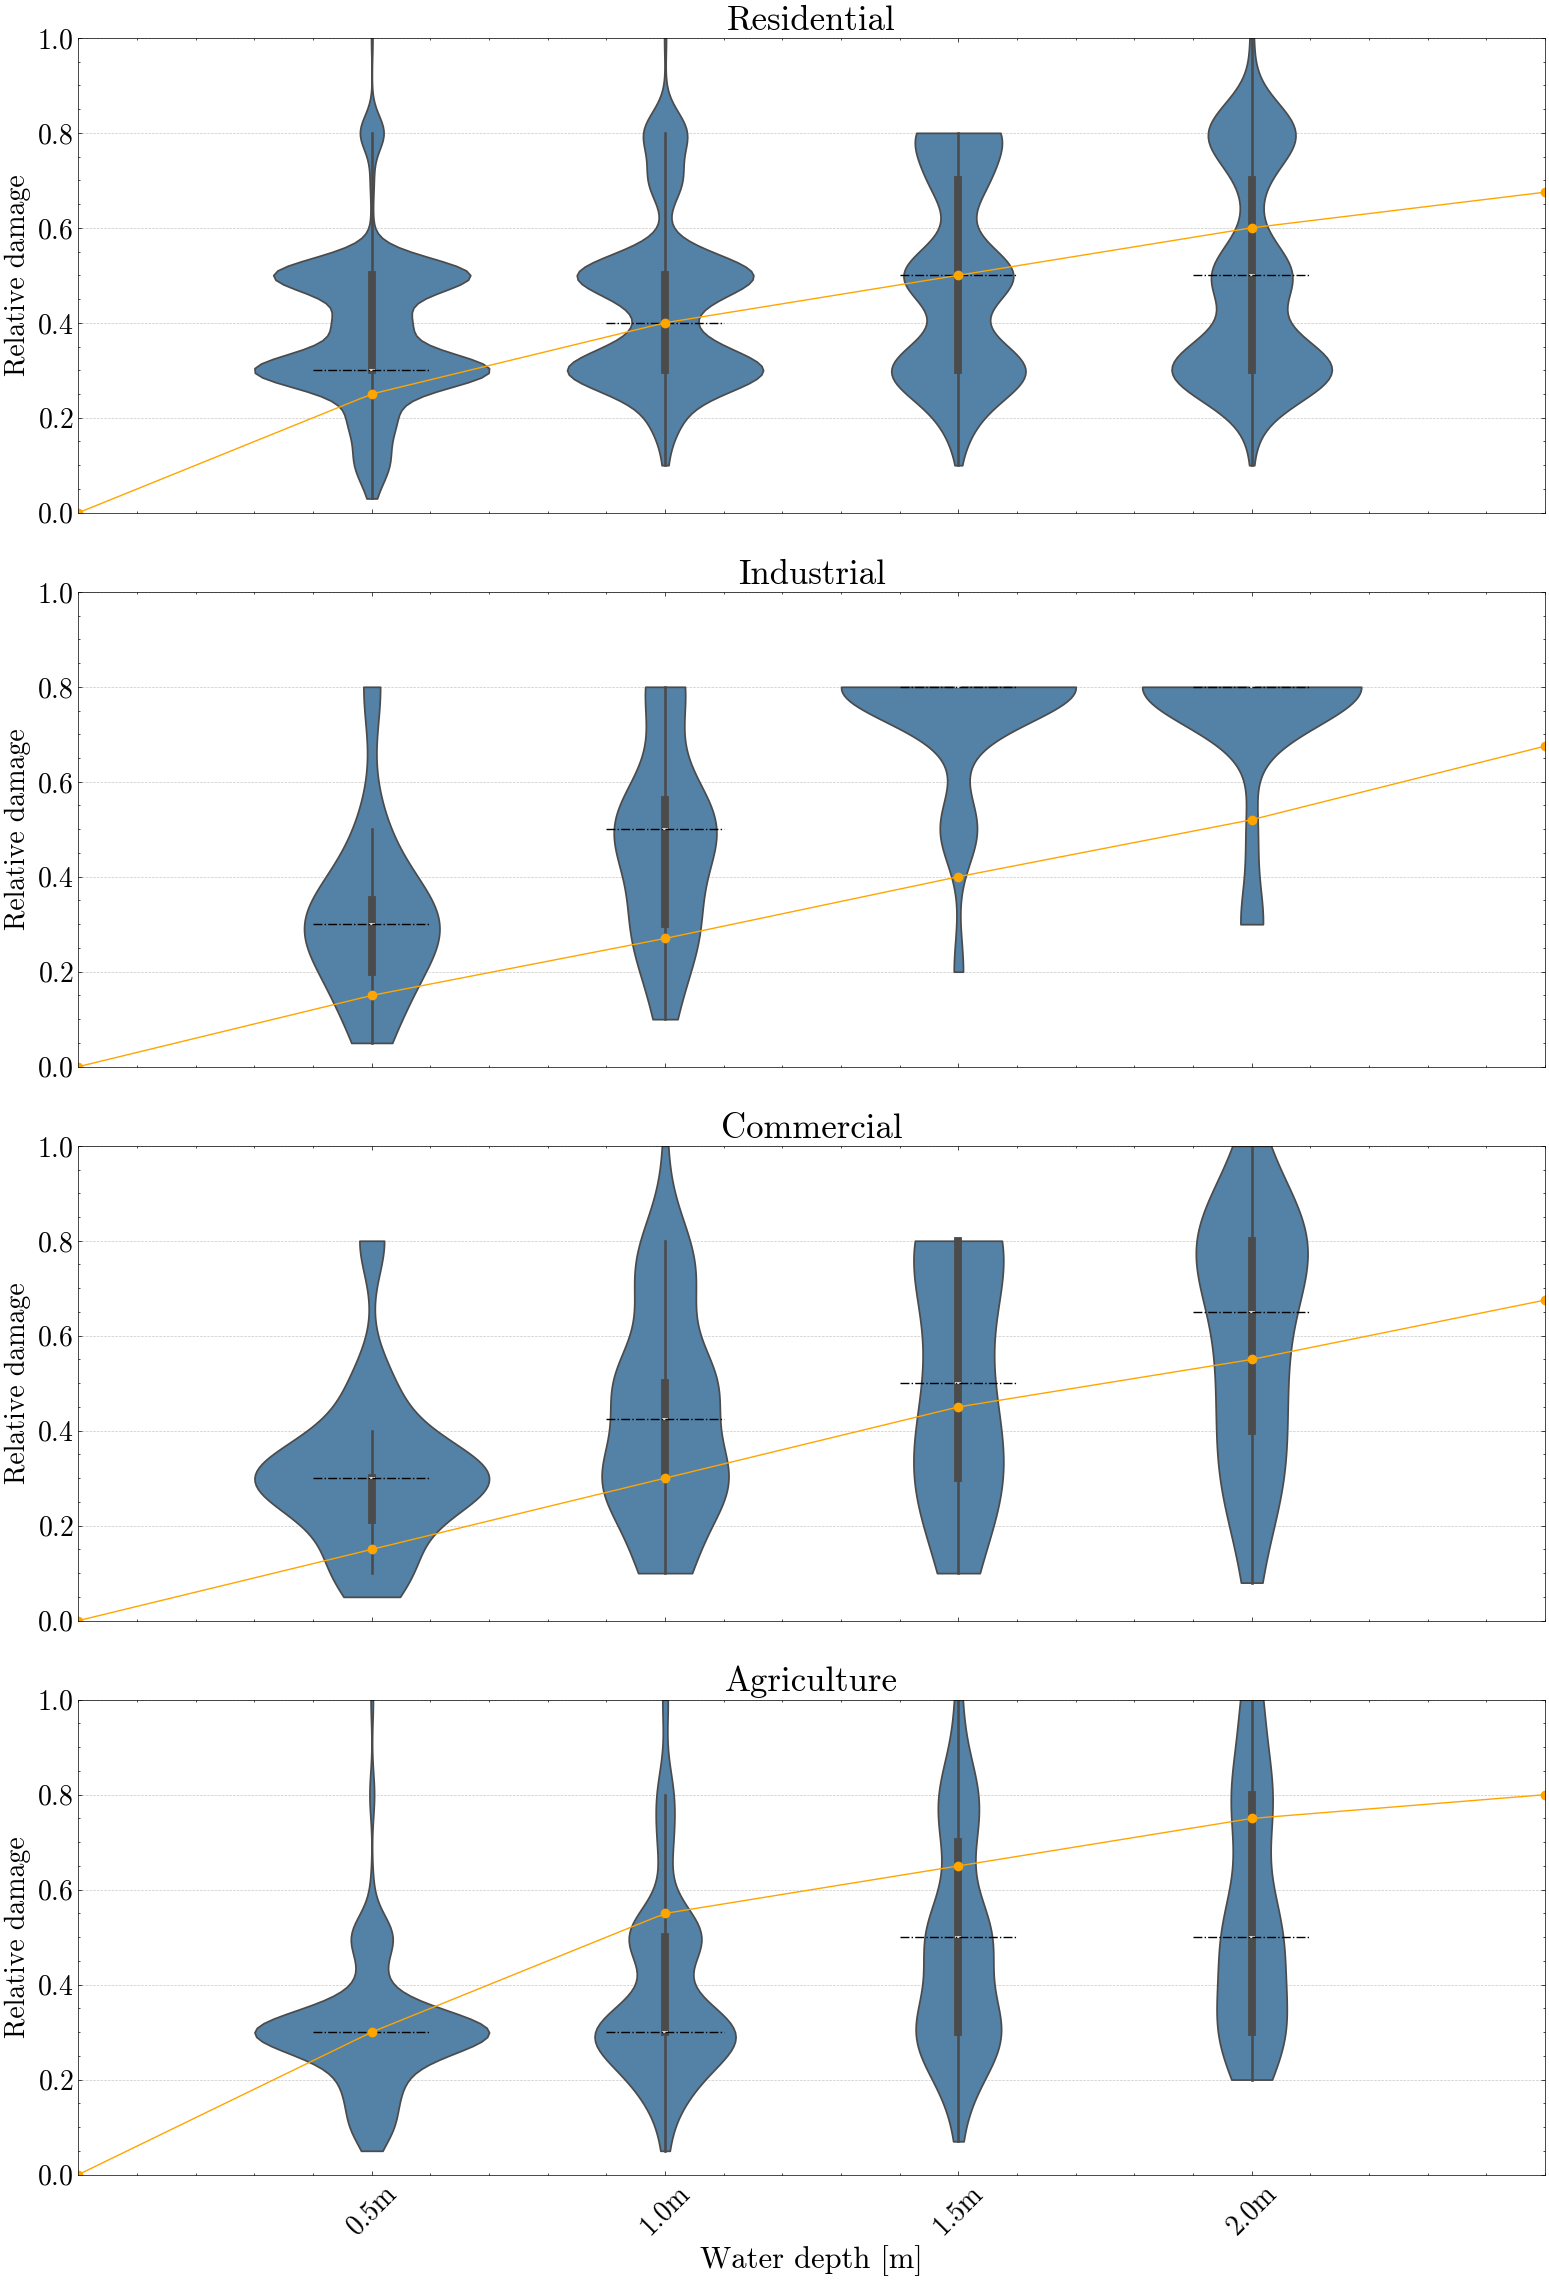

In [134]:
fontsize = 20
sizefactor = 0.8
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(20*sizefactor, 29*sizefactor))

# Increase text font size
original_font_size = plt.rcParams['font.size']
print(f"Original font size: {original_font_size}")

for no, (property_type, damage_function) in enumerate([
    ("residential", residential_damage_fractions),
    ("industrial", industrial_damage_function),
    ("commercial", commercial_damage_function),
    ("agriculture", agriculture_damage_function),
]):  
    plt.rcParams.update({'font.size': fontsize})
    _df = df.copy()
    _df = _df[_df["property_type"] == property_type]

    ax = axes[no]
    
    # _df = _df[_df["Objekt_VrstaObjektaId"].isin(vrste_objekta_id)]
    # plot_violin_damage_by_water_height(_df)
    fig, ax = plot_violin_damage_by_water_height(_df, title="NO", ax=ax)#title=property_type, title="NO")
    fig, ax = plot_damage_function(damage_function, color="orange", label=property_type.capitalize() + " DDF", ax=ax)
    
    # ax.legend()
    ax.set_title(property_type.capitalize(), fontsize=fontsize + 5)
    # Hide x-axis ticks
    if no != 3:
        ax.set_xlabel(None)
        ax.set_xticklabels([])

    # plt.savefig(IMAGES_PATH + f"/05/violin_damage_by_water_height_bucker_{property_type}.pdf", dpi=300, bbox_inches="tight")
    

axes[-1].set_xlabel("Water depth [m]", fontsize=fontsize+2, fontweight="bold")
# axes[-1].tick_params(axis="x", labelrotation=45)

plt.savefig(IMAGES_PATH + f"/05/violin_damage_by_water_height_bucket_all.pdf", dpi=300, bbox_inches="tight")

plt.rcParams.update({'font.size': original_font_size})

# Damage Function Performance Metrics

This section calculates advanced metrics to assess the performance of damage functions compared to observed data.



In [23]:
from scipy.stats import spearmanr

def calculate_error_metrics_by_depth_bucket(df):
    """
    Calculate Mean Relative Error by Depth Bucket (MREb).
    
    MREb calculates the average relative error for observations within specific 
    depth intervals. Allows assessment of damage function performance across 
    different flood severity levels.
    
    Args:
        df: DataFrame with flood depth and damage observations
        
    Returns:
        dict: Dictionary with bucket ranges as keys and MRE values as values
    """
    # Create depth buckets
    df_copy = df.copy()
    
    # Create bucket labels
    bucket_labels = []
    for i in range(len(bucket_edges) - 1):
        bucket_labels.append(f"{bucket_edges[i]:.1f}-{bucket_edges[i+1]:.1f}m")
    
    # Remove observations with NaN bucket (beyond max_depth)
    df_copy = df_copy.dropna(subset=["water_height_bucket"])
    
    bucket_mre = {}
    bucket_stats = {}
    
    for bucket in bucket_labels:
        bucket_data = df_copy[df_copy["water_height_bucket"] == bucket]
        
        if len(bucket_data) == 0:
            continue
            
        # Get predicted damage using the damage function
        predicted_damage = bucket_data["predicted_relative_damage"]
        observed_damage = bucket_data["relative_damage"]
        
        # Calculate relative error for each observation
        # RE = (predicted - observed) / observed
        # For observed damage = 0, we use absolute error instead
        relative_errors = []
        for pred, obs in zip(predicted_damage, observed_damage):
            if obs == 0:
                # Use absolute error when observed damage is 0
                re = abs(pred - obs)
            else:
                re = abs(pred - obs) / obs
            relative_errors.append(re)
        
        # Calculate mean relative error for this bucket
        mre = np.mean(relative_errors)
        bucket_mre[bucket] = mre
        
        # Store additional statistics
        bucket_stats[bucket] = {
            "count": len(bucket_data),
            "mean_observed": np.mean(observed_damage),
            "mean_predicted": np.mean(predicted_damage),
            # rmse
            "rmse": np.sqrt(np.mean([(pred - obs)**2 for pred, obs in zip(predicted_damage, observed_damage)])),
            "mre": mre,
            "std_relative_error": np.std(relative_errors)
        }
    
    return bucket_mre, bucket_stats

def calculate_spearman_correlation(df):
    """
    Calculate Spearman Correlation (ρs) between predicted and observed damage rankings.
    
    ρs measures the monotonic relationship between predicted and observed damage rankings. 
    Values close to 1 indicate strong positive correlation, suggesting the damage function 
    captures the relative ordering of impacts well.
    
    Args:
        df: DataFrame with flood depth and damage observations
        depth_col: Column name for flood depth in meters  
        damage_col: Column name for observed relative damage (0-1 scale)
        
    Returns:
        tuple: (correlation_coefficient, p_value)
    """
    # Remove any rows with missing data
    df_clean = df[["predicted_relative_damage", "relative_damage"]].dropna()
    
    # Get predicted damage using the damage function
    predicted_damage = df_clean["predicted_relative_damage"]
    observed_damage = df_clean["relative_damage"]
    
    # Calculate Spearman correlation
    correlation, p_value = spearmanr(predicted_damage, observed_damage)
    
    return correlation, p_value

def plot_mre_by_depth_bucket(bucket_mre, bucket_stats):
    """Plot Mean Relative Error by depth bucket."""
    buckets = list(bucket_mre.keys())
    mre_values = list(bucket_mre.values())
    counts = [bucket_stats[bucket]["count"] for bucket in buckets]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot MRE values
    bars1 = ax1.bar(buckets, mre_values, color="steelblue", alpha=0.7)
    ax1.set_ylabel("Mean Relative Error (MRE)")
    ax1.set_title("Mean Relative Error by Depth Bucket")
    ax1.grid(True, alpha=0.3)
    
    # Add count labels on bars
    for bar, count in zip(bars1, counts):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                f"n={count}", ha="center", va="bottom", fontsize=10)
    
    # Plot sample counts
    bars2 = ax2.bar(buckets, counts, color="orange", alpha=0.7)
    ax2.set_ylabel("Sample Count")
    ax2.set_xlabel("Depth Bucket")
    ax2.set_title("Number of Observations by Depth Bucket")
    ax2.grid(True, alpha=0.3)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig

def plot_predicted_vs_observed_scatter(df):
    """Create scatter plot of predicted vs observed damage with Spearman correlation."""
    # Remove any rows with missing data
    df_clean = df[["predicted_relative_damage", "relative_damage"]].dropna()
    
    # Get predicted damage using the damage function
    predicted_damage = df_clean["predicted_relative_damage"]
    observed_damage = df_clean["relative_damage"]
    
    # Calculate Spearman correlation
    correlation, p_value = spearmanr(predicted_damage, observed_damage)
    
    # Create scatter plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create density plot for better visualization of overlapping points
    scatter = ax.scatter(observed_damage, predicted_damage, alpha=0.6, s=30)
    
    # Add perfect prediction line (y=x)
    max_val = max(max(predicted_damage), max(observed_damage))
    ax.plot([0, max_val], [0, max_val], "r--", alpha=0.8, linewidth=2, 
            label="Perfect prediction (y=x)")
    
    ax.set_xlabel("Observed Relative Damage")
    ax.set_ylabel("Predicted Relative Damage")
    ax.set_title(f"Predicted vs Observed Damage\\nSpearman ρ = {correlation:.3f} (p = {p_value:.3e})")
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Set equal aspect ratio and limits
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_aspect("equal")
    
    plt.tight_layout()
    return fig, correlation, p_value


## 1. Mean Relative Error by Depth Bucket (MREb)

Calculate and visualize the MREb metric across different flood depth intervals.


In [55]:
# Calculate MREb for the entire dataset
bucket_mre, bucket_stats = calculate_error_metrics_by_depth_bucket(df)

# Display results
print("Mean Relative Error by Depth Bucket (MREb):")
print("=" * 50)
for bucket, mre in bucket_mre.items():
    stats = bucket_stats[bucket]
    print(f"{bucket:>12}: MRE = {mre:.3f} (n={stats['count']:>4}, "
          f"mean_obs={stats['mean_observed']:.3f}, "
          f"mean_pred={stats['mean_predicted']:.3f}, "
          f"rmse={stats['rmse']:.3f})")

# Calculate overall statistics
overall_mre = np.mean(list(bucket_mre.values()))
print(f"\nOverall MREb (average across buckets): {overall_mre:.3f}")

overall_rmse = np.mean([stats['rmse'] for stats in bucket_stats.values()])
print(f"Overall RMSE (average across buckets): {overall_rmse:.3f}")

total_observations = sum(stats['count'] for stats in bucket_stats.values())
print(f"Total observations used: {total_observations}")
print(f"Total dataset size: {len(df)}")
print(f"Coverage: {total_observations/len(df)*100:.1f}%")


Mean Relative Error by Depth Bucket (MREb):
    0.0-0.5m: MRE = 0.544 (n=1527, mean_obs=0.365, mean_pred=0.165, rmse=0.257)
    0.5-1.0m: MRE = 0.400 (n=1144, mean_obs=0.428, mean_pred=0.351, rmse=0.208)
    1.0-1.5m: MRE = 0.476 (n= 659, mean_obs=0.503, mean_pred=0.478, rmse=0.231)
    1.5-2.0m: MRE = 0.572 (n= 497, mean_obs=0.513, mean_pred=0.575, rmse=0.245)

Overall MREb (average across buckets): 0.498
Overall RMSE (average across buckets): 0.235
Total observations used: 3827
Total dataset size: 4200
Coverage: 91.1%


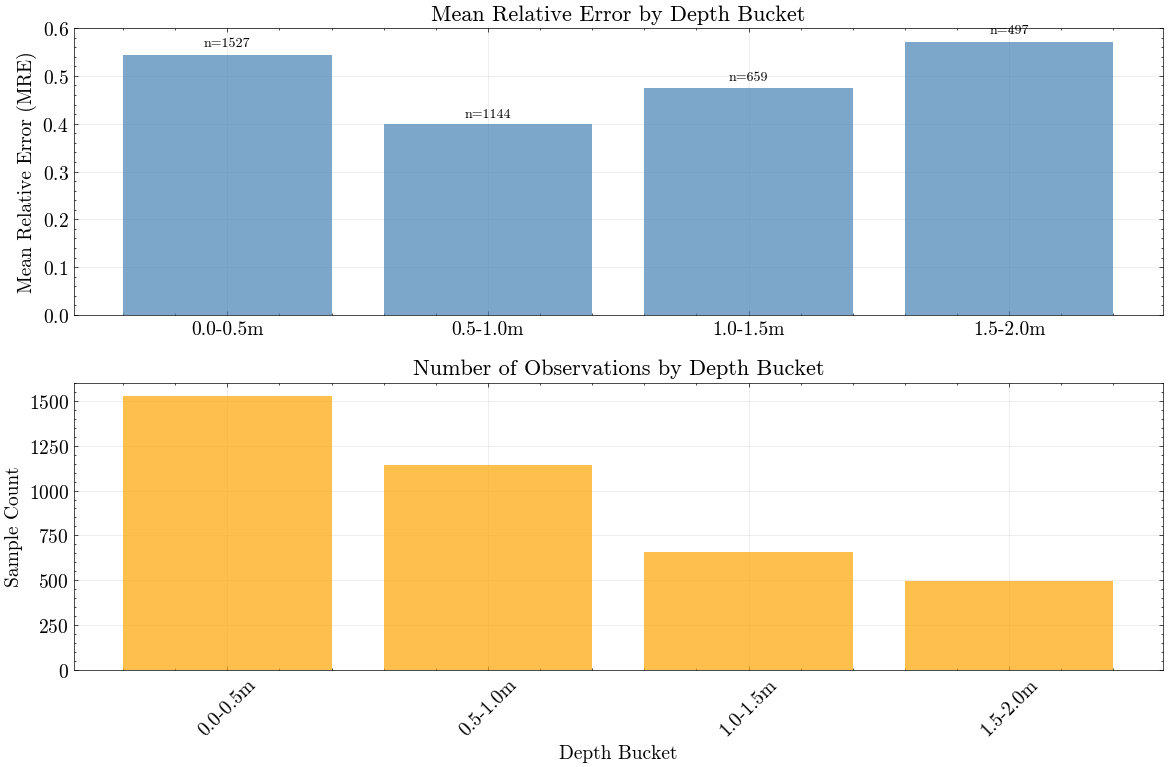

In [57]:
# # Plot MREb visualization
fig = plot_mre_by_depth_bucket(bucket_mre, bucket_stats)
plt.savefig(IMAGES_PATH + "/05/mre_by_depth_bucket.pdf", dpi=300, bbox_inches="tight")
plt.show()


## 2. Spearman Correlation (ρs)

Calculate and visualize the Spearman correlation between predicted and observed damage rankings.


In [58]:
# Calculate Spearman correlation for the entire dataset
correlation, p_value = calculate_spearman_correlation(
    df
)

print("Spearman Correlation Analysis:")
print("=" * 40)
print(f"Spearman correlation coefficient (ρs): {correlation:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"Sample size: {len(df[['Objekt_VisinaVodeM', 'relative_damage']].dropna())}")

# Interpret the correlation strength
if abs(correlation) >= 0.7:
    strength = "strong"
elif abs(correlation) >= 0.5:
    strength = "moderate"
elif abs(correlation) >= 0.3:
    strength = "weak"
else:
    strength = "very weak"

direction = "positive" if correlation > 0 else "negative"
significance = "significant" if p_value < 0.05 else "not significant"

print(f"\nInterpretation:")
print(f"- Correlation strength: {strength} {direction} correlation")
print(f"- Statistical significance: {significance} (α = 0.05)")

if correlation > 0.5:
    print("- The damage function captures the relative ordering of impacts reasonably well")
else:
    print("- The damage function may not adequately capture the relative ordering of impacts")


Spearman Correlation Analysis:
Spearman correlation coefficient (ρs): 0.2439
P-value: 6.41e-58
Sample size: 4200

Interpretation:
- Correlation strength: very weak positive correlation
- Statistical significance: significant (α = 0.05)
- The damage function may not adequately capture the relative ordering of impacts


/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_45360/1858668773.py:163: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) cmr10.
  plt.tight_layout()
/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_45360/1038170978.py:5: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) cmr10.
  plt.savefig(IMAGES_PATH + "/05/predicted_vs_observed_damage_scatter.pdf", dpi=300, bbox_inches="tight")
/var/folders/ly/jtbv8d056fx1pnpygvdlzn0r0000gn/T/ipykernel_45360/1038170978.py:5: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) cmr10.
  plt.savefig(IMAGES_PATH + "/05/predicted_vs_observed_damage_scatter.pdf", dpi=300, bbox_inches="tight")
/Users/klemenkubelj/miniconda3/envs/cvar-masters/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


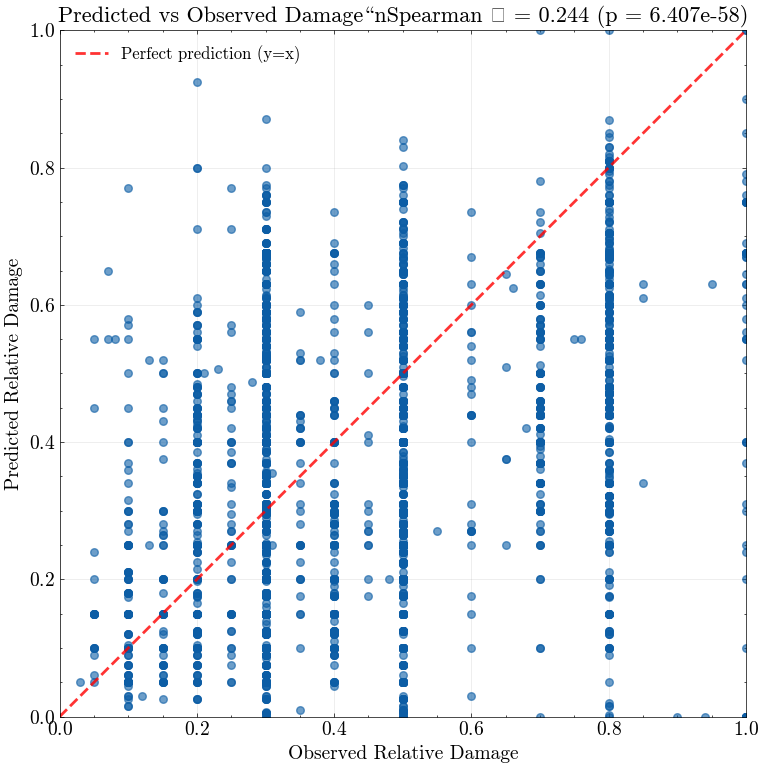

In [59]:
# # Create scatter plot of predicted vs observed damage
fig, corr, p_val = plot_predicted_vs_observed_scatter(
    df
)
plt.savefig(IMAGES_PATH + "/05/predicted_vs_observed_damage_scatter.pdf", dpi=300, bbox_inches="tight")
plt.show()


## 3. Analysis by Building Type

Calculate metrics separately for different building types to understand performance variations.


In [63]:
# Define building type mappings
property_types = [
    "residential",
    "industrial",
    "commercial",
    "agriculture",
]

print("Analysis by Building Type:")
print("=" * 50)

# Store results for comparison
building_type_results = {}

for property_type in property_types:
    # Filter data for this building type
    type_df = df[df["property_type"] == property_type]
    
    if len(type_df) < 10:  # Skip if too few samples
        print(f"\n{property_type}: Insufficient data (n={len(type_df)})")
        continue
    
    print(f"\n{property_type}:")
    print(f"Sample size: {len(type_df)}")
    
    # Calculate MREb for this building type
    bucket_mre_type, bucket_stats_type = calculate_error_metrics_by_depth_bucket(
        type_df,
    )
    
    # Sum rms for all buckets
    # Calculate Spearman correlation
    correlation_type, p_value_type = calculate_spearman_correlation(
        type_df,
    )
    
    # Calculate overall MREb
    if bucket_mre_type:
        overall_mre_type = np.mean(list(bucket_mre_type.values()))
        all_rmses = [bucket_stats_type[bucket]['rmse'] for bucket in bucket_stats_type]
        overall_rmse_type = np.mean(all_rmses)
        print(f"Overall MREb: {overall_mre_type:.3f}")
    else:
        overall_mre_type = overall_rmse_type = None
        print("Overall MREb: No data in depth buckets")
    
    print(f"Spearman ρs: {correlation_type:.4f} (p = {p_value_type:.2e})")
    
    # Store results
    building_type_results[property_type] = {
        "sample_size": len(type_df),
        "overall_mre": overall_mre_type,
        "overall_rmse": overall_rmse_type,
        "spearman_correlation": correlation_type,
        "spearman_p_value": p_value_type,
        "bucket_mre": bucket_mre_type,
        "bucket_stats": bucket_stats_type,
    }


Analysis by Building Type:

residential:
Sample size: 3249
Overall MREb: 0.462
Spearman ρs: 0.2266 (p = 4.07e-39)

industrial:
Sample size: 147
Overall MREb: 0.528
Spearman ρs: 0.6063 (p = 4.02e-16)

commercial:
Sample size: 218
Overall MREb: 0.574
Spearman ρs: 0.4815 (p = 4.70e-14)

agriculture:
Sample size: 586
Overall MREb: 0.617
Spearman ρs: 0.3487 (p = 3.42e-18)


In [66]:
# Create summary table of results
print("\n\nSummary Table:")
print("=" * 80)
print(f"{'Building Type':<20} {'Sample Size':<12} {'MREb':<8} {'Spearman ρs':<12} {'P-value':<10} {'RMSE':<10}")
print("-" * 80)

for type_name, results in building_type_results.items():
    mre_str = f"{results['overall_mre']:.3f}" if results['overall_mre'] is not None else "N/A"
    rmse_str = f"{results['overall_rmse']:.3f}" if results['overall_rmse'] is not None else "N/A"
    print(
        f"{type_name:<20} {results['sample_size']:<12} {mre_str:<8} "
        f"{results['spearman_correlation']:<12.4f} {results['spearman_p_value']:<10.2e}"
        f"{rmse_str}"
    )

# Overall results
print("-" * 80)
print(
    f"{'Overall (All Types)':<20} {len(df):<12} {overall_mre:<8.3f} "
    f"{correlation:<12.4f} {p_value:<10.2e}"
    f"{overall_rmse:<12.3f}"
)




Summary Table:
Building Type        Sample Size  MREb     Spearman ρs  P-value    RMSE      
--------------------------------------------------------------------------------
residential          3249         0.462    0.2266       4.07e-39  0.225
industrial           147          0.528    0.6063       4.02e-16  0.327
commercial           218          0.574    0.4815       4.70e-14  0.263
agriculture          586          0.617    0.3487       3.42e-18  0.229
--------------------------------------------------------------------------------
Overall (All Types)  4200         0.498    0.2439       6.41e-58  0.235       


## 4. Summary and Interpretation

The calculated metrics provide insights into the performance of the JRC depth-damage function when applied to Slovenian flood damage data:


In [67]:
print("Key Findings:")
print("=" * 50)

print(f"\n1. Mean Relative Error by Depth Bucket (MREb): {overall_mre:.3f}")
print("   - This measures the average relative error across different flood depth intervals")
print("   - Lower values indicate better performance")
print("   - Values > 1.0 suggest the model systematically over- or under-predicts damage")

print(f"\n2. Spearman Correlation (ρs): {correlation:.4f}")
print("   - This measures how well the damage function captures relative damage rankings")
print("   - Values close to 1.0 indicate strong monotonic relationship")
print("   - Values close to 0 indicate poor ranking performance")

if correlation > 0.7:
    ranking_performance = "excellent"
elif correlation > 0.5:
    ranking_performance = "good"
elif correlation > 0.3:
    ranking_performance = "moderate"
else:
    ranking_performance = "poor"

print(f"\n3. Overall Assessment:")
print(f"   - Ranking performance: {ranking_performance}")
print(f"   - Statistical significance: {'Yes' if p_value < 0.05 else 'No'} (p = {p_value:.2e})")

# Identify best and worst performing building types
if building_type_results:
    valid_results = {k: v for k, v in building_type_results.items() 
                    if v['overall_mre'] is not None}
    
    if valid_results:
        best_mre_type = min(valid_results.keys(), key=lambda x: valid_results[x]['overall_mre'])
        worst_mre_type = max(valid_results.keys(), key=lambda x: valid_results[x]['overall_mre'])
        
        best_corr_type = max(valid_results.keys(), key=lambda x: valid_results[x]['spearman_correlation'])
        worst_corr_type = min(valid_results.keys(), key=lambda x: valid_results[x]['spearman_correlation'])
        
        print(f"\n4. Building Type Performance:")
        print(f"   - Best MREb performance: {best_mre_type} ({valid_results[best_mre_type]['overall_mre']:.3f})")
        print(f"   - Worst MREb performance: {worst_mre_type} ({valid_results[worst_mre_type]['overall_mre']:.3f})")
        print(f"   - Best correlation: {best_corr_type} ({valid_results[best_corr_type]['spearman_correlation']:.3f})")
        print(f"   - Worst correlation: {worst_corr_type} ({valid_results[worst_corr_type]['spearman_correlation']:.3f})")

print(f"\n5. Data Coverage:")
print(f"   - Total observations: {len(df):,}")
print(f"   - Observations with flood depth ≤ 3m: {total_observations:,} ({total_observations/len(df)*100:.1f}%)")
print(f"   - This analysis focuses on the most common flood depth range")


Key Findings:

1. Mean Relative Error by Depth Bucket (MREb): 0.498
   - This measures the average relative error across different flood depth intervals
   - Lower values indicate better performance
   - Values > 1.0 suggest the model systematically over- or under-predicts damage

2. Spearman Correlation (ρs): 0.2439
   - This measures how well the damage function captures relative damage rankings
   - Values close to 1.0 indicate strong monotonic relationship
   - Values close to 0 indicate poor ranking performance

3. Overall Assessment:
   - Ranking performance: poor
   - Statistical significance: Yes (p = 6.41e-58)

4. Building Type Performance:
   - Best MREb performance: residential (0.462)
   - Worst MREb performance: agriculture (0.617)
   - Best correlation: industrial (0.606)
   - Worst correlation: residential (0.227)

5. Data Coverage:
   - Total observations: 4,200
   - Observations with flood depth ≤ 3m: 3,827 (91.1%)
   - This analysis focuses on the most common flood de

In [90]:
def plot_four_property_types_onecol(
    df,
    bucket_edges,
    figsize=(12, 16),
    add_ddf=True,
    suptitle=None,
    save_path=None,
):
    """
    Plot four subplots (1 column x 4 rows), one per property_type, sharing the x-axis.
    Each subplot shows the violin distribution of observed relative damage by water-depth bucket
    and optionally overlays the corresponding depth-damage function sampled at bucket centers.

    Args:
        df (pd.DataFrame): Input dataframe with columns "property_type", "water_height_bucket", and "relative_damage".
        bucket_edges (array-like): Numeric bin edges used to create the buckets.
        figsize (tuple): Figure size.
        add_ddf (bool): If True, overlay the damage function curve sampled at bucket centers.
        suptitle (str|None): Optional figure title.
        save_path (str|None): If provided, save the figure to this path.

    Returns:
        (fig, axes): Matplotlib figure and axes array of length 4.
    """
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy.interpolate import interp1d

    property_types = [
        "residential",
        "industrial",
        "commercial",
        "agriculture",
    ]

    # Map property types to damage functions and colors
    ddf_map = {
        "residential": residential_damage_fractions,
        "industrial": industrial_damage_function,
        "commercial": commercial_damage_function,
        "agriculture": agriculture_damage_function,
    }
    color_map = {
        "residential": "orange",
        "industrial": "purple",
        "commercial": "red",
        "agriculture": "green",
    }

    # Prepare x mapping: categories are positioned at 0..n-1; we label with bucket upper bounds
    num_bins = len(bucket_edges) - 1
    x_positions = np.arange(num_bins)
    bucket_labels = [f"{x}m" for x in bucket_edges[1:]]
    centers_m = 0.5 * (np.array(bucket_edges[:-1]) + np.array(bucket_edges[1:]))

    fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=figsize)

    for idx, ptype in enumerate(property_types):
        ax = axes[idx]
        sub_df = df[df["property_type"] == ptype].copy()

        # Violin plot on this axis
        sns.violinplot(
            data=sub_df,
            x="water_height_bucket",
            y="relative_damage",
            cut=0,
            ax=ax,
        )

        # Force x positions to 0..n-1 with desired numeric tick labels
        ax.set_xticks(x_positions)
        ax.set_xticklabels(bucket_labels)

        # Y limits and grid
        ax.set_ylim(0, 1)
        ax.grid(True, axis="y", linestyle="--", alpha=0.7)

        # Median markers per bucket
        medians = sub_df.groupby("water_height_bucket", observed=False)["relative_damage"].median()
        for i, median in enumerate(medians):
            ax.hlines(median, i - 0.2, i + 0.2, colors="black", linestyles="-.", alpha=1)

        # Overlay DDF sampled at bucket centers
        if add_ddf and ptype in ddf_map:
            ddf = [(h, d) for h, d in ddf_map[ptype] if h <= bucket_edges[-1]]
            if len(ddf) >= 2:
                depths = np.array([h for h, _ in ddf])
                losses = np.array([d for _, d in ddf])
                f = interp1d(depths, losses, kind="linear", bounds_error=False, fill_value=(0, 1))
                y_vals = np.clip(f(centers_m), 0, 1)
                ax.plot(x_positions, y_vals, "-o", color=color_map[ptype], label=f"{ptype.capitalize()} DDF")
                ax.legend()

        # Titles and y-labels
        ax.set_title(f"{ptype.capitalize()} (n={len(sub_df)})")
        ax.set_ylabel("Relative damage")

        # Hide x tick labels for all but the bottom axis
        if idx < len(property_types) - 1:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

    # Bottom axis x label
    axes[-1].set_xlabel("Water depth [m]")
    axes[-1].tick_params(axis="x", labelrotation=45)

    if suptitle:
        fig.suptitle(suptitle)
        fig.tight_layout(rect=[0, 0, 1, 0.97])
    else:
        fig.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes


(<Figure size 1200x1600 with 4 Axes>,
 array([<Axes: title={'center': 'Residential (n=3249)'}, ylabel='Relative damage'>,
        <Axes: title={'center': 'Industrial (n=147)'}, ylabel='Relative damage'>,
        <Axes: title={'center': 'Commercial (n=218)'}, ylabel='Relative damage'>,
        <Axes: title={'center': 'Agriculture (n=586)'}, xlabel='Water depth [m]', ylabel='Relative damage'>],
       dtype=object))

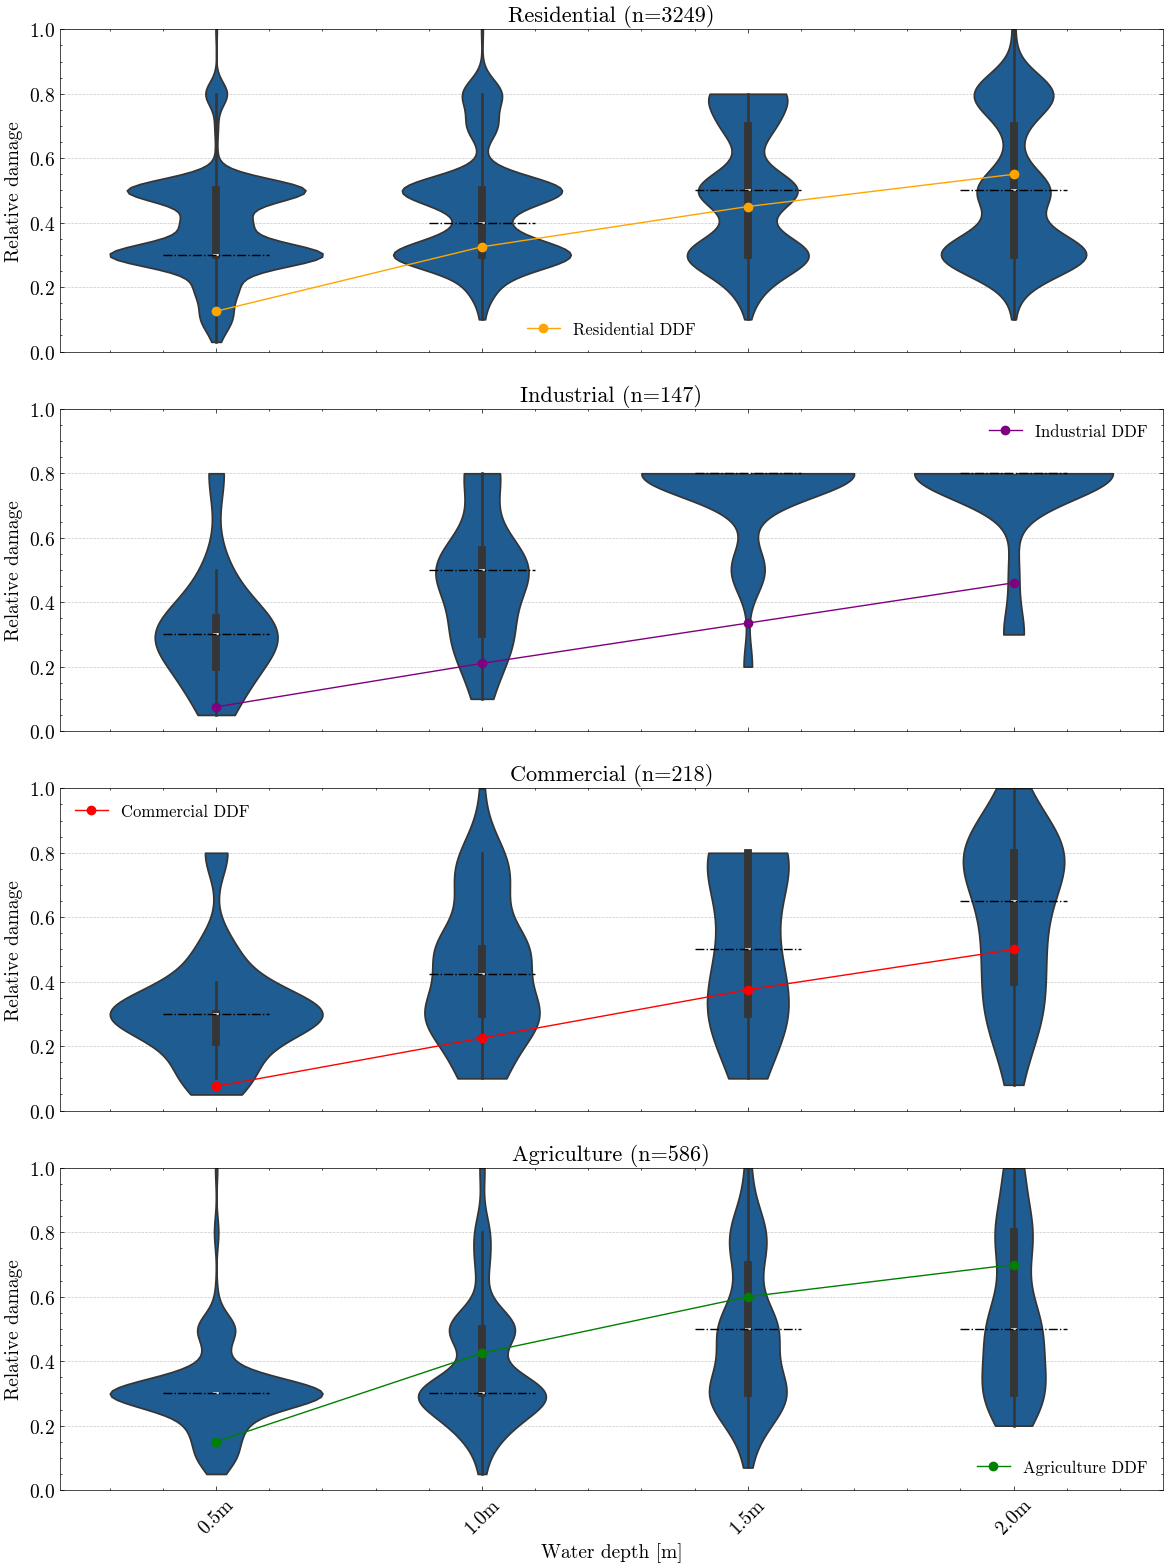

In [91]:
plot_four_property_types_onecol(df, bucket_edges)